# Test ABL with K-epsilon model

In [1]:
# Add any possible locations of amr-wind-frontend here
import sys, os
curdir = os.getcwd()
extradirs = ['../', './',
             os.path.dirname(curdir),
            ]
for x in extradirs: sys.path.insert(1, x)

import numpy as np
import matplotlib.pyplot as plt
import SANDwake3D_keps as SANDwake3D

In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import time
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
from mpl_toolkits.axes_grid1 import make_axes_locatable
#?solve_ivp

## Set mesh and BC's 

In [3]:
# Set up mesh and BL parameters
Uinf = 1.0
nu   = 1.5E-5 # m^2/s

# y-z mesh 
#zmin = 1
#zmax = 120
#Nz   = int((zmax-zmin)/1.0+1)
zmin = 5
zmax = 200
Nz   = int((zmax-zmin)/5.0+1)
zvec = np.linspace(zmin,zmax,Nz)

Ny=51
ymax = 125
yvec = np.linspace(-ymax,ymax,Ny)

# x grid
xvecplot = [0, 10]

In [4]:
ym, zm = np.meshgrid(yvec, zvec, indexing='ij')

dy   = np.mean(np.diff(yvec))
dz   = np.mean(np.diff(zvec))
print(f'dy = {dy}')
print(f'dz = {dz}')
print(ym.shape)

dy = 5.0
dz = 5.0
(51, 40)


In [5]:
# Set ABL parameters
ABLparam = {
    'ustar' : 0.4, #0.575652,
    'L' : float('inf'),
    'kappa' : 0.42,
    'rho' : 1.225,
    'z0' : 0.15,
    'Cmu' : 5.48**(-2),
}

# This parameter defines V(z) -- m/s per meter
veerpermeter = 0.0 #0.02

In [6]:
def tanhwake(y, z, zhh, turbR, delta, U1, U0=0):
    r = np.sqrt(y**2 + (z-zhh)**2)
    Ur = 0.5*(U1-U0)*(1.0 + np.tanh((r-turbR)/delta)) + U0
    return -Ur

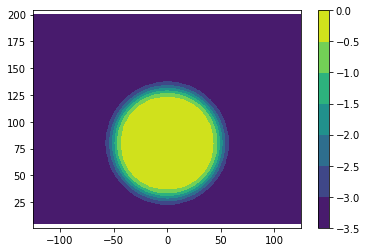

In [7]:
turbhh = 80
turbR  = 50
wakedef= 3.5
rdelta = 7.5 #10.0
wakeU  = wakedef*np.exp(-2.0*(ym**2 + (zm-turbhh)**2)/turbR**2)
wakeUr = tanhwake(ym, zm, turbhh, turbR, rdelta, wakedef)
plt.contourf(ym, zm, wakeUr)
plt.axis('equal')
plt.colorbar()

In [8]:
# Set up ABL profile
UABL = np.zeros(Nz)
for iz, z in enumerate(zvec):
    UABL[iz] = SANDwake3D.init_U_ABL(z,ABLparam)
    
# Set up veer profile
veerV = np.zeros(Nz)
for i, z in enumerate(zvec):
    veerV[i] = veerpermeter*(z-turbhh)
    
# Compute the wind direction
ztop = turbhh + turbR
zbot = turbhh - turbR
Utop, Ubot = np.interp(ztop, zvec, UABL), np.interp(zbot, zvec, UABL)
Vtop, Vbot = np.interp(ztop, zvec, veerV), np.interp(zbot, zvec, veerV)
Wdirtop = np.arctan2(Vtop, Utop)*180/np.pi
Wdirbot = np.arctan2(Vbot, Ubot)*180/np.pi

Uhh, Vhh = np.interp(turbhh, zvec, UABL), np.interp(turbhh, zvec, UABL)
alpha = np.log(Utop/Ubot)/np.log(ztop/zbot)
print('Uhh = ',Uhh)
print('alpha = ',alpha)
print('rotor veer = ',Wdirtop-Wdirbot)

Uhh =  5.980139637675966
alpha =  0.1666205486623225
rotor veer =  0.0


In [9]:
Uinit  = np.zeros((Ny, Nz))
Vinit  = np.zeros((Ny, Nz))
Winit  = np.zeros((Ny, Nz))
Kinit  = np.zeros((Ny, Nz))
Tinit  = np.ones((Ny, Nz))*300
EPSinit= np.zeros((Ny, Nz))

for iz, z in enumerate(zvec):
    Uinit[:, iz] = UABL[iz] #SANDwake3D.init_U_ABL(z,ABLparam)
    Vinit[:, iz] = veerV[iz]
    Winit[:, iz] = 0.0
    Kinit[:, iz]   = SANDwake3D.init_k_ABL(z,ABLparam)*1.0 #0.2
    EPSinit[:, iz] = 5.0E-3 #9.75E-4 #5.0E-4 #SANDwake3D.init_e_ABL(z,ABLparam)*0.1  #5.0E-4 is good
    #EPSinit[:, iz] = SANDwake3D.init_e_ABL(z,ABLparam)*0.50  #5.0E-4 is good
    
Uinit = Uinit - wakeUr
#for iy, y in enumerate(yvec):
#    Kinit[iy,:]   = SANDwake3D.set_k_init(zvec, dz, Uinit[0,:],ABLparam,k_factor=0.1)
#    EPSinit[iy,:] = SANDwake3D.set_e_init(zvec, dz, Uinit[0,:], Kinit[0,:], ABLparam)
#Kinit[:,0] = Kinit[:,1]
#Kinit[:,-2] = Kinit[:,-1]
#EPSinit[:,0] = EPSinit[:,1]
#EPSinit[:,-2] = EPSinit[:,-1]

phiinit = {}
phiinit['u'] = Uinit
phiinit['v'] = Vinit
phiinit['w'] = Winit
phiinit['k'] = Kinit
phiinit['T'] = Tinit
phiinit['eps'] = EPSinit

(0.0, 200.0)

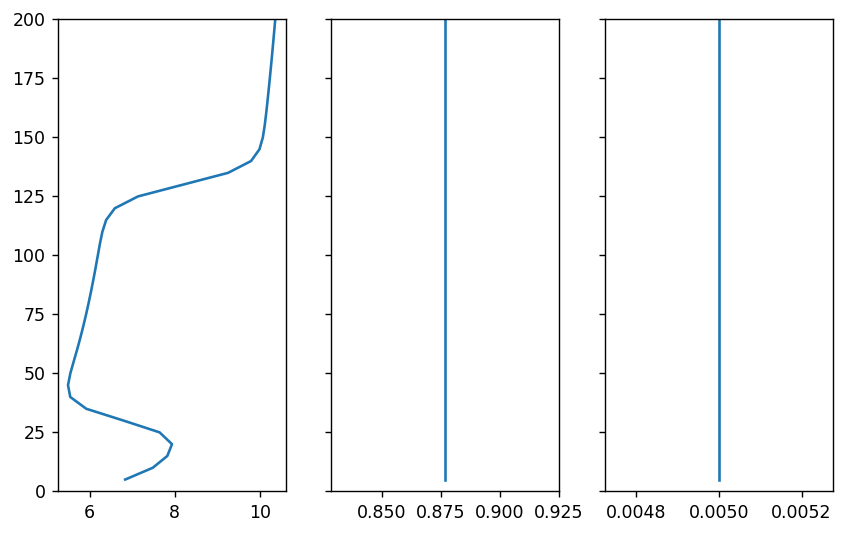

In [10]:
fig, axs = plt.subplots(1,3, sharey=True, dpi=125, figsize=(8,5))
axs[0].plot(Uinit[Ny//2,:], zvec)
axs[1].plot(Kinit[Ny//2,:], zvec)
axs[2].plot(EPSinit[Ny//2,:], zvec)
axs[0].set_ylim([0, zmax])

In [11]:
# Set boundary conditions
ubc = {}
ubc['ylo'] = {'type':'neumann', 'value':0.0}
ubc['yhi'] = {'type':'neumann', 'value':0.0}
ubc['zlo'] = {'type':'bcfunc', 'value':None, 'tag':'MyZLO_UBC', 
              'func':(lambda phi, aux, param: {'u':{'zlo':{'type':'dirichlet','value':Uinit[0,0]}}})}
#ubc['zlo'] = {'type':'dirichlet', 'value':Uinit[0,0]}
ubc['zhi'] = {'type':'dirichlet', 'value':Uinit[0,-1]}

vbc = {}
vbc['ylo'] = {'type':'dirichlet', 'value':veerV}
vbc['yhi'] = {'type':'dirichlet', 'value':0.0}
vbc['zlo'] = {'type':'dirichlet', 'value':0.0}
vbc['zhi'] = {'type':'dirichlet', 'value':0.0}

wbc = {}
wbc['ylo'] = {'type':'neumann', 'value':0.0}
wbc['yhi'] = {'type':'neumann', 'value':0.0}
wbc['zlo'] = {'type':'dirichlet', 'value':0.0}
wbc['zhi'] = {'type':'neumann', 'value':0.0}

kbc = {}
kbc['ylo'] = {'type':'neumann', 'value':0.0}
kbc['yhi'] = {'type':'neumann', 'value':0.0}
kbc['zlo'] = {'type':'dirichlet', 'value':Kinit[0,0]}
kbc['zhi'] = {'type':'neumann', 'value':0.0}

epsbc = {}
epsbc['ylo'] = {'type':'neumann', 'value':0.0}
epsbc['yhi'] = {'type':'neumann', 'value':0.0}
epsbc['zlo'] = {'type':'dirichlet', 'value':EPSinit[0,0]}
epsbc['zhi'] = {'type':'neumann', 'value':0.0}

Tbc = {}
Tbc['ylo'] = {'type':'dirichlet', 'value':300}
Tbc['yhi'] = {'type':'dirichlet', 'value':300}
Tbc['zlo'] = {'type':'dirichlet', 'value':300}
Tbc['zhi'] = {'type':'dirichlet', 'value':300}

allbc = {'u':ubc, 'v':vbc, 'w':wbc, 'k':kbc, 'eps':epsbc, 'T':Tbc}

In [12]:
# Set parameters
params = {
    'nu' : nu,
    'Cmu' : 5.48**(-2),
    #'Cmu'  : 0.01,
    'C1eps' : 1.76,
    'C2eps' : 1.92,
    'C3eps' : 0.033,
    'sigmak' : 1.0,
    'sigmaeps' : 1.3,
    'sigmaT':1.0,
}
#params['nu']       = nu
#params['Cmu']      = 0.0
#params['C1eps']    = 0.0
#params['C2eps']    = 0.0
#params['C3eps']    = 0.0
#params['sigmak']   = 1.0
#params['sigmaeps'] = 1.0

In [13]:
xvecplot=[0, 200, 300, 400, 500] #[0, 100]#[0, 100, 200, 300]
dx  = 20 #25
#firstxvec = [xvecplot[0], xvecplot[0]+5, xvecplot[0]+10]
#xvec = np.concatenate((firstxvec, np.arange(firstxvec[-1]+dx, xvecplot[-1]+1.0E-6, dx)))

#xvec = [0, 10, 20, 30, 40]
xvec = np.arange(xvecplot[0], xvecplot[-1]+1.0E-6, dx)
#xvec = [0, 10, 20]

#xvec = [0.0, 2.5, 5.0, 7.5, 10, 15, 20, 25, 30]
#xvec = np.arange(xvecplot[0], xvecplot[0]+dx+1.0E-6, dx)

#xvec = xvecplot
start_time = time.time()
phi = SANDwake3D.marchSystem(phiinit, xvec, dy, dz, params, allbc, SANDwake3D.kepsT_eqns, 
                             advanceSys=SANDwake3D.advanceSystemKEPS,
                             verbose=True, maxiter=100, tol=1.0E-4)
end_time = time.time()
execution_time = end_time - start_time
print(f"Execution time: {execution_time:.4f} seconds")

x = 20.0 dx = 20.0
0 {'u': 3.553346706379987, 'w': 0.0, 'k': 4.930556164717142, 'eps': 0.050464511265456403, 'T': 2.6812987050722666e-12, 'v': 0.0}
1 {'u': 0.2133163984303828, 'w': 0.0, 'k': 0.6678869394555099, 'eps': 0.0029230782684911954, 'T': 3.4290294779238303e-12, 'v': 11.67640994121499}
2 {'u': 0.49566788538046014, 'w': 0.0, 'k': 0.22518940475630742, 'eps': 0.0017400832210999603, 'T': 3.0478887807599926e-12, 'v': 0.424136135334906}
3 {'u': 0.029355865960333485, 'w': 0.0, 'k': 0.05956819681749682, 'eps': 0.0007276463533447677, 'T': 3.2345853334065384e-12, 'v': 1.341665047955603}
4 {'u': 0.06472563772287873, 'w': 0.0, 'k': 0.009915592731466572, 'eps': 0.00016724416914426892, 'T': 3.046828461096401e-12, 'v': 0.041160007807595864}
5 {'u': 0.001764154407339137, 'w': 0.0, 'k': 0.005970585690954557, 'eps': 8.060821759370682e-05, 'T': 2.9234322188639886e-12, 'v': 0.12461532880285246}
6 {'u': 0.0044298696871796885, 'w': 0.0, 'k': 0.00047665043538017377, 'eps': 1.0686274951566693e-05, 'T':

8 {'u': 0.00023823853365117554, 'w': 0.0, 'k': 9.472186794374269e-05, 'eps': 1.3815007610992328e-06, 'T': 3.1238031770121975e-12, 'v': 0.0007751315429454186}
9 {'u': 2.134280180160777e-05, 'w': 0.0, 'k': 1.2109465574777002e-05, 'eps': 1.8171343468558311e-07, 'T': 2.9311588796994642e-12, 'v': 0.0005832259415352997}
10 {'u': 1.5030645093386492e-05, 'w': 0.0, 'k': 6.728670366475437e-06, 'eps': 9.669830128136786e-08, 'T': 3.0008803182262255e-12, 'v': 5.996053235465608e-05}
x = 120.0 dx = 20.0
0 {'u': 1.5720268993773845, 'w': 0.0, 'k': 0.9408200320827397, 'eps': 0.01476216113352538, 'T': 2.7231498204408774e-12, 'v': 7.573118256180767}
1 {'u': 0.2835130614361199, 'w': 0.0, 'k': 0.13801773290077962, 'eps': 0.0020886823073114668, 'T': 3.0547718876151528e-12, 'v': 6.901189167891688}
2 {'u': 0.26328081368843037, 'w': 0.0, 'k': 0.08270159855179353, 'eps': 0.0013126521535318737, 'T': 3.1837389462772184e-12, 'v': 0.9721743969754695}
3 {'u': 0.036387107474898706, 'w': 0.0, 'k': 0.010179394251987679,

1 {'u': 0.16829440020784733, 'w': 0.0, 'k': 0.06874890684491022, 'eps': 0.0011469860047874738, 'T': 3.0191294456220706e-12, 'v': 4.613236266851333}
2 {'u': 0.15934765070686122, 'w': 0.0, 'k': 0.05609755575081108, 'eps': 0.0009290117878394727, 'T': 3.070070901319645e-12, 'v': 0.6241535330964745}
3 {'u': 0.019905880217481423, 'w': 0.0, 'k': 0.006993019591351268, 'eps': 0.00011016999332788241, 'T': 3.154681718458871e-12, 'v': 0.5818779735518267}
4 {'u': 0.018248403978428973, 'w': 0.0, 'k': 0.007418176252002556, 'eps': 0.0001176612761793873, 'T': 3.0489487316808405e-12, 'v': 0.05647176432218066}
5 {'u': 0.0013591844917926203, 'w': 0.0, 'k': 0.0007027688425919953, 'eps': 1.0952106516146126e-05, 'T': 3.005721752379551e-12, 'v': 0.05073540053573831}
6 {'u': 0.0011859657914314178, 'w': 0.0, 'k': 0.0005983868159024458, 'eps': 9.187554296483423e-06, 'T': 3.0727009633982513e-12, 'v': 0.004412983454359355}
7 {'u': 0.00010333088026669873, 'w': 0.0, 'k': 6.528119114242116e-05, 'eps': 1.0400728977895

x = 320.0 dx = 20.0
0 {'u': 0.7755559204261961, 'w': 0.0, 'k': 0.3361184481533437, 'eps': 0.004656420216931773, 'T': 2.7189936970674804e-12, 'v': 3.5394684333637643}
1 {'u': 0.11035277257671358, 'w': 0.0, 'k': 0.040809557124419915, 'eps': 0.0006801660704396671, 'T': 3.2220743198123246e-12, 'v': 3.3557864406760496}
2 {'u': 0.1048526229228176, 'w': 0.0, 'k': 0.03563514250503023, 'eps': 0.0005918047617504651, 'T': 3.0905260289428467e-12, 'v': 0.43352660601245546}
3 {'u': 0.012110656002409853, 'w': 0.0, 'k': 0.004559258779456176, 'eps': 7.177743389576921e-05, 'T': 3.1103272750225308e-12, 'v': 0.4062251388115957}
4 {'u': 0.011210375228710271, 'w': 0.0, 'k': 0.0045592796809233345, 'eps': 7.136097508851917e-05, 'T': 3.191847813779181e-12, 'v': 0.03532272755343211}
5 {'u': 0.0007249989522648775, 'w': 0.0, 'k': 0.00039996742467838283, 'eps': 6.218065778279255e-06, 'T': 3.18018481509611e-12, 'v': 0.03197830499123974}
6 {'u': 0.0006431696511701635, 'w': 0.0, 'k': 0.0003297097526295284, 'eps': 4.9

4 {'u': 0.0072071631635753156, 'w': 0.0, 'k': 0.0028169027310876327, 'eps': 4.285827924348226e-05, 'T': 3.123285948235242e-12, 'v': 0.02246593994955876}
5 {'u': 0.0004013610151370602, 'w': 0.0, 'k': 0.00022665045549890336, 'eps': 3.4410429018072002e-06, 'T': 3.0957491626827737e-12, 'v': 0.02049510673213655}
6 {'u': 0.00036218879087062387, 'w': 0.0, 'k': 0.00018103409806952267, 'eps': 2.6663704777551773e-06, 'T': 3.1953889725980836e-12, 'v': 0.001386878430852451}
7 {'u': 2.40591924839213e-05, 'w': 0.0, 'k': 1.6361689576964108e-05, 'eps': 2.493623213927529e-07, 'T': 3.065331102951123e-12, 'v': 0.001217244580417523}
8 {'u': 2.0832611195793995e-05, 'w': 0.0, 'k': 1.0275466186982007e-05, 'eps': 1.5067135434180183e-07, 'T': 3.028746233384759e-12, 'v': 6.918411068150515e-05}
x = 440.0 dx = 20.0
0 {'u': 0.5944459421246098, 'w': 0.0, 'k': 0.3104861172339041, 'eps': 0.004536759297282226, 'T': 2.7690389194546243e-12, 'v': 2.519267083715555}
1 {'u': 0.06963332514611184, 'w': 0.0, 'k': 0.0229944961

(5.0, 200.0)

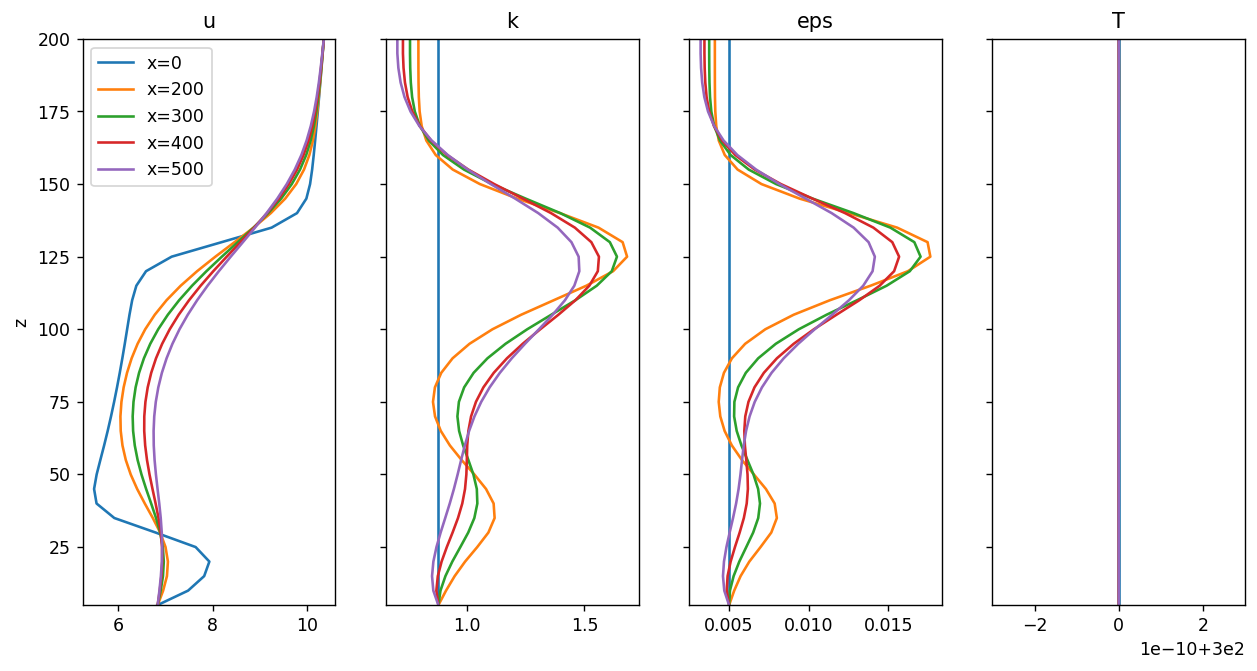

In [14]:
plotvars=['u', 'k', 'eps', 'T']
islice = Ny//2
find_nearest = lambda a, a0: np.abs(np.array(a) - a0).argmin()

fig, axs = plt.subplots(1,len(plotvars),figsize=(12,6), dpi=125, sharey=True)
for iv, v in enumerate(plotvars):
    #axs[iv].plot(np.mean(phi[v][0,:,:], axis=0), zvec,)
    #axs[iv].plot(np.mean(phi[v][-1,:,:], axis=0), zvec,)
    #axs[iv].plot(phi[v][0,islice,:], zvec,)
    #axs[iv].plot(phi[v][-1,islice,:], zvec,)    
    for x in xvecplot:
        ixRANS = find_nearest(xvec, x)
        axs[iv].plot(phi[v][ixRANS,islice,:], zvec, label='x=%.0f'%x)
    axs[iv].set_title(v)
    
axs[0].legend()
axs[0].set_ylabel('z')
axs[0].set_ylim([zmin, zmax])

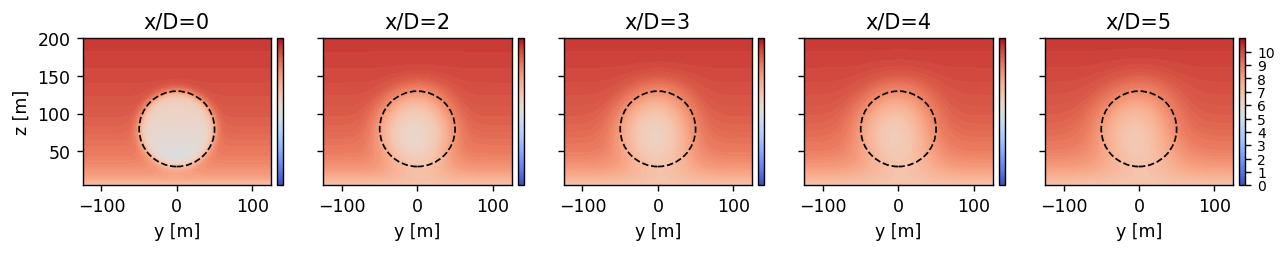

In [15]:
savefigs = False
cbarticks=np.arange(0,11,1)

fig, axs = plt.subplots(1, len(xvecplot), figsize=(12,3.25), dpi=125, sharey=True)
for ix, x in enumerate(xvecplot):
    ixRANS = find_nearest(xvec, x)
    c=axs[ix].contourf(ym, zm, phi['u'][ixRANS,:,:], levels=np.linspace(0,11,91), cmap='coolwarm')
    axs[ix].set_aspect('equal')
    axs[ix].set_title('x/D=%.0f'%(0.5*x/turbR))
    axs[ix].set_xlabel('y [m]')
    rotorcirc = plt.Circle((0.0, turbhh), turbR, color='k', linestyle='--', fill=False)
    axs[ix].add_patch(rotorcirc)
    
    divider = make_axes_locatable(axs[ix])
    cax = divider.append_axes("right", size="3%", pad=0.05)
    if ix < len(xvecplot)-1:
        cbar=fig.colorbar(c, ax=axs[ix], cax=cax, ticks = matplotlib.ticker.FixedLocator([]))
    else:
        cbar=fig.colorbar(c, ax=axs[ix], cax=cax,ticks = matplotlib.ticker.FixedLocator(cbarticks))
        cbar.ax.tick_params(labelsize=8)
        
axs[0].set_ylabel('z [m]')

if savefigs:
    plt.tight_layout()
    plt.savefig('TestABL_KEPST.png')

In [16]:
print(phi['u'].shape)

(26, 51, 40)
